In [1]:
import torch
print(torch.__version__)

2.12.0+cpu


In [ ]:
import numpy as np

# 初始化一个简单的 tensor
tensor1 = torch.tensor([1, 2, 3])
print("初始化的tensor:", tensor1)

# 将 ndarray 转成 tensor
ndarray = np.array([4, 5, 6])
tensor2 = torch.from_numpy(ndarray)
print("由ndarray转成的tensor:", tensor2)

# 将 tensor 转成 ndarray
tensor_to_nd = tensor2.numpy()
print("由tensor转成的ndarray:", tensor_to_nd)

初始化的tensor: tensor([1, 2, 3])
由ndarray转成的tensor: tensor([4, 5, 6])
由tensor转成的ndarray: [4 5 6]


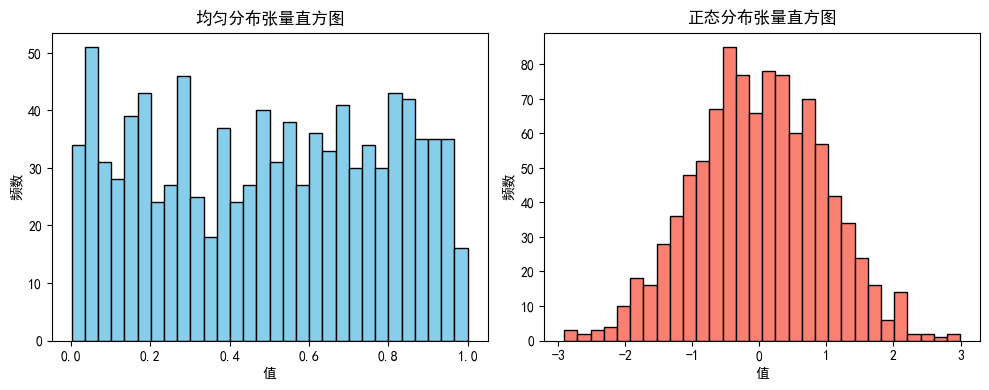

In [3]:
import matplotlib.pyplot as plt

# 设置matplotlib的中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']   # 使用黑体显示中文
plt.rcParams['axes.unicode_minus'] = False     # 正确显示负号

# 创建均匀分布的张量
uniform_tensor = torch.rand(1000)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(uniform_tensor.numpy(), bins=30, color='skyblue', edgecolor='black')
plt.title("均匀分布张量直方图")
plt.xlabel("值")
plt.ylabel("频数")

# 创建正态分布的张量
normal_tensor = torch.randn(1000)
plt.subplot(1,2,2)
plt.hist(normal_tensor.numpy(), bins=30, color='salmon', edgecolor='black')
plt.title("正态分布张量直方图")
plt.xlabel("值")
plt.ylabel("频数")

plt.tight_layout()
plt.show()

In [4]:
# 演示 add 和 _add 的区别
a = torch.tensor([1, 2, 3])
b = torch.tensor([4, 5, 6])

# 使用 add（不会改变原a）
c = a.add(b)
print("a.add(b) 结果:", c)
print("add 后的 a:", a)   # a 不变

# 使用 add_（会修改原a）
a.add_(b)
print("a.add_(b) 后的 a:", a)   # a 被改变

a.add(b) 结果: tensor([5, 7, 9])
add 后的 a: tensor([1, 2, 3])
a.add_(b) 后的 a: tensor([5, 7, 9])


In [5]:
# 创建一个形状为(3, 4, 1)的张量
x = torch.randn(3, 4, 1)
print("原始张量形状:", x.shape)

# 删除一个轴（去掉最后一个为1的维度）
x_squeezed = x.squeeze()
print("删除轴后的形状 (squeeze):", x_squeezed.shape)
print(x_squeezed)

# 指定删除某个具体的轴（假如只想去掉最后一个）
x_squeezed_last = x.squeeze(-1)
print("只删除最后一个轴后的形状:", x_squeezed_last.shape)

# 添加一个轴（在第1维插入一个新轴）
x_unsqueezed = x_squeezed.unsqueeze(1)
print("添加一个新轴后的形状 (unsqueeze 第1维):", x_unsqueezed.shape)
print(x_unsqueezed)

# 也可以在-1（最后）添加一维
x_unsqueezed_last = x_squeezed.unsqueeze(-1)
print("在末尾添加新轴后的形状:", x_unsqueezed_last.shape)

原始张量形状: torch.Size([3, 4, 1])
删除轴后的形状 (squeeze): torch.Size([3, 4])
tensor([[ 1.2116, -0.7137, -1.2664, -0.8511],
        [ 1.2420, -0.3409,  1.8799, -1.3006],
        [-0.5084, -0.4467,  0.6142, -1.1719]])
只删除最后一个轴后的形状: torch.Size([3, 4])
添加一个新轴后的形状 (unsqueeze 第1维): torch.Size([3, 1, 4])
tensor([[[ 1.2116, -0.7137, -1.2664, -0.8511]],

        [[ 1.2420, -0.3409,  1.8799, -1.3006]],

        [[-0.5084, -0.4467,  0.6142, -1.1719]]])
在末尾添加新轴后的形状: torch.Size([3, 4, 1])


In [6]:
# 初始化一个 shape 为 (2,3,4) 的张量
tensor = torch.randn(2, 3, 4)
print("原始张量 shape:", tensor.shape)

# 先通过transpose使张量变为非连续内存
tensor_t = tensor.transpose(0, 1)
print("transpose(0,1) 后的 shape:", tensor_t.shape)
print("tensor_t 是否为内存连续:", tensor_t.is_contiguous())

tensor_t=tensor.contiguous()
# 尝试对非连续内存的张量使用view会报错
try:
    tensor_view = tensor_t.view(3, -1)
except Exception as e:
    print("view(3, -1) 报错信息:", e)
# 使用 view 变换为 shape (3, -1)
tensor_view = tensor.view(3, -1)
print("view(3, -1) 后的 shape:", tensor_view.shape)

原始张量 shape: torch.Size([2, 3, 4])
transpose(0,1) 后的 shape: torch.Size([3, 2, 4])
tensor_t 是否为内存连续: False
view(3, -1) 后的 shape: torch.Size([3, 8])


# 求梯度

In [7]:
import torch
# 1. 准备数据: 参数与目标值
x = torch.tensor(5) #特征
y = torch.tensor(0.)
# 2. 初始化参数: 权重与偏置
w = torch.tensor(1., requires_grad=True, dtype=torch.float32)
b = torch.tensor(3., requires_grad=True, dtype=torch.float32)
# 3. 构建神经网络并输出值
z = w * x + b
# 4. 计算损失
loss = torch.nn.MSELoss()
loss = loss(z, y)
# 5. 反向传播，自动微分，计算梯度
loss.backward()
# 6. 访问梯度
print(w.grad)
print(b.grad)


tensor(80.)
tensor(16.)


# 线性回归

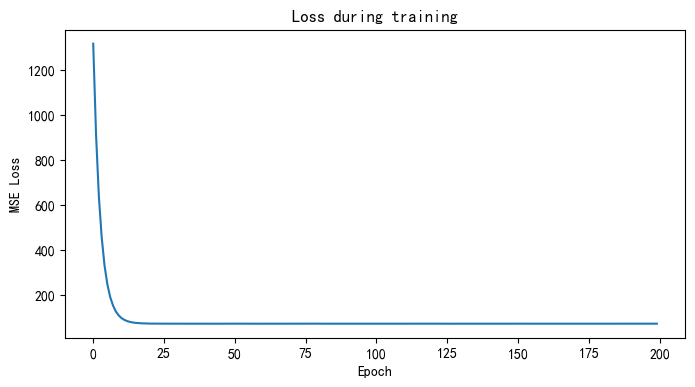

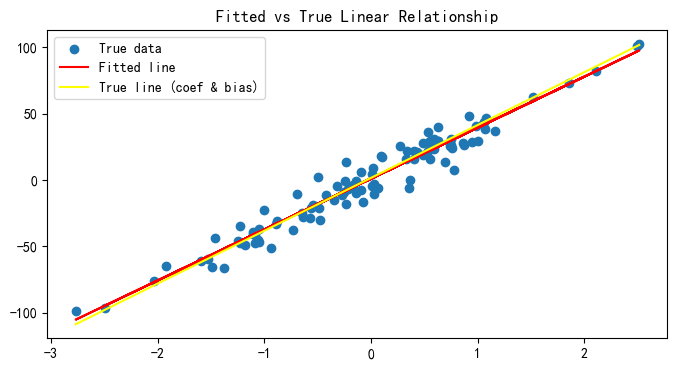

Learned weight: 38.364139556884766
Learned bias: 0.9791136980056763
True coef: 39.80551570183919


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

# 1. 生成数据，coef就是w
x, y, coef = make_regression(n_samples=100, n_features=1, noise=10, bias=1.5, coef=True, random_state=22)
x = x.astype('float32')
y = y.astype('float32').reshape(-1, 1)

from torch.utils.data import TensorDataset, DataLoader

# 创建Dataset对象
dataset = TensorDataset(torch.from_numpy(x), torch.from_numpy(y))

# 创建DataLoader对象，batch_size=10
dataloader = DataLoader(dataset, batch_size=10, shuffle=True)

# 转为torch tensor
X = torch.from_numpy(x)
Y = torch.from_numpy(y)

# 2. 模型搭建（单层Linear层）
model = nn.Linear(1, 1)

# 3. 损失函数与优化器
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)


# 4. 训练模型
losses = []
for epoch in range(200):
    epoch_loss = 0.0    # 用于累计本轮总损失
    for xb, yb in dataloader:  # 对DataLoader中每个batch进行训练
        y_pred = model(xb)                # 前向传播
        loss = criterion(y_pred, yb)      # 计算损失
        optimizer.zero_grad()             # 梯度清零
        loss.backward()                   # 反向传播
        optimizer.step()                  # 更新参数
        epoch_loss += loss.item() * xb.shape[0]  # 加权累计损失
    losses.append(epoch_loss / len(X))           # 记录每轮平均损失

# 5. 可视化结果
plt.figure(figsize=(8,4))
plt.plot(losses)
plt.title('Loss during training')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.show()

# 同时绘制拟合的红线和真实的绿色线
plt.figure(figsize=(8,4))
plt.scatter(X.numpy(), Y.numpy(), label='True data')
with torch.no_grad():
    y_fit = model(X).numpy()
# 拟合结果（红线）
plt.plot(X.numpy(), y_fit, color='red', label='Fitted line')
# 真实直线（黄线）
x_sorted = X.numpy().flatten()
sort_idx = x_sorted.argsort()
x_sorted = x_sorted[sort_idx]
y_true = coef * x_sorted + 1.5
plt.plot(x_sorted, y_true, color='yellow', label='True line (coef & bias)')
plt.title('Fitted vs True Linear Relationship')
plt.legend()
plt.show()

# 打印模型参数
print("Learned weight:", model.weight.item())
print("Learned bias:", model.bias.item())
print("True coef:", coef)